[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/carlosfab/bootcamp-visao-computacional-drones/blob/main/aula-02/03-saidas-detector.ipynb)

Nos notebooks anteriores, visualizamos detecções e acompanhamos a formação de
mapas de características. Agora vamos examinar **o que um detector retorna**
e como esses dados se relacionam com a imagem anotada.

Execute a preparação antes de começar. Este notebook funciona de forma independente
no Colab, em CPU ou GPU, e utiliza a mesma imagem sintética da praça.

In [1]:
from urllib.request import urlretrieve
base = "https://raw.githubusercontent.com/carlosfab/bootcamp-visao-computacional-drones/c041e096bb0fb17f9c9c5d80df9a16c4c1e04a8a/"
urlretrieve(base + "dados/aula-02/praca-sintetica.png", "praca.png")
urlretrieve(base + "apoio/aula02_saidas.py", "apoio_saidas.py");
urlretrieve(base + "dados/aula-02/formatos-caixas.png", "formatos-caixas.png");

In [2]:
import torch
from PIL import Image
from torchvision.transforms.functional import pil_to_tensor

In [3]:
from torchvision.ops import box_convert
import apoio_saidas as apoio

**O que a divisão em recortes permite observar?**

Na grade do primeiro notebook, executamos o detector completo em cada recorte
e mostramos as classes encontradas. Agora vamos examinar as limitações de uma
busca que analisa muitas regiões independentemente.

A cena abaixo tem 768 × 512 pixels. Nenhuma anotação será acrescentada à entrada do modelo.

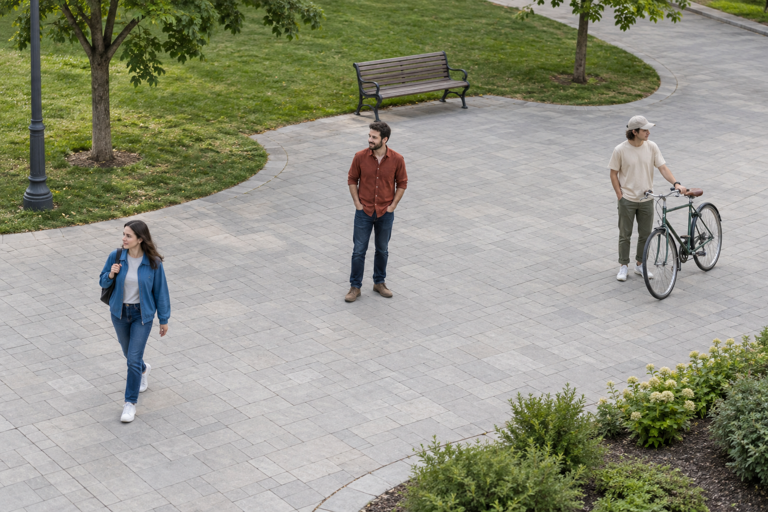

In [4]:
foto = Image.open("praca.png").convert("RGB").resize((768, 512))
imagem = pil_to_tensor(foto)
foto

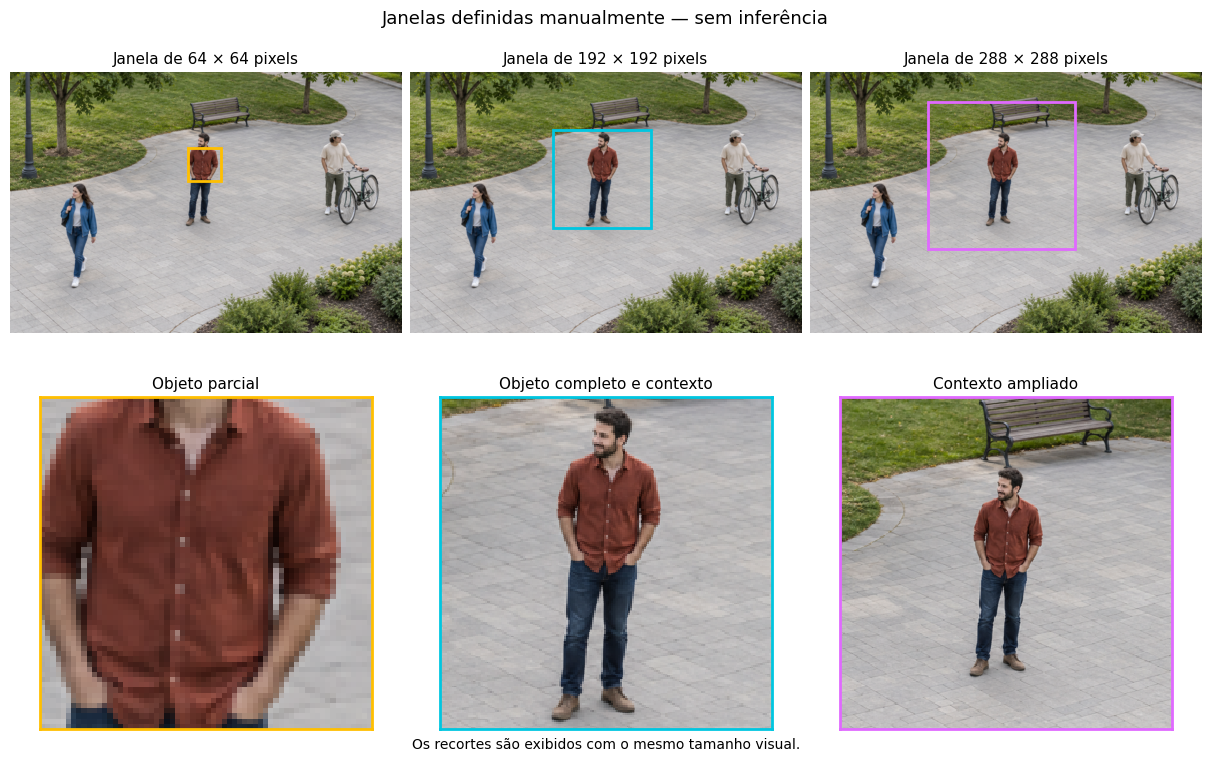

In [5]:
apoio.comparar_recortes(imagem)

As três janelas foram escolhidas manualmente. Elas mostram porções diferentes
da pessoa central: uma região pequena, uma região maior e mais contexto.
Os recortes são ampliados para comparação; confira suas dimensões nos rótulos.

Uma janela pode cortar um objeto ou conter várias instâncias. Mesmo quando um
classificador reconhece uma categoria no recorte, os limites da janela não
necessariamente coincidem com os limites do objeto.

**Quantas regiões uma janela deslizante percorre?**

Vamos contar janelas quadradas de 128 pixels. O passo é o deslocamento entre
posições. Consideramos apenas posições em que a janela cabe inteiramente,
partindo da origem, sem padding nem ajuste adicional na borda.

In [6]:
largura, altura = foto.size
tamanho = 128
passo = 64

In [7]:
colunas = (largura - tamanho) // passo + 1
linhas = (altura - tamanho) // passo + 1
linhas * colunas

77

São 77 janelas para **um tamanho e um formato**. Altere `passo` para `32` e
reexecute a contagem: serão 273. Outros tamanhos e proporções acrescentam regiões.
Esta conta não executa inferências e não é uma medição de tempo.

Ao processar cada recorte independentemente, repetimos cálculos sobre áreas
sobrepostas. Também precisamos lidar com objetos cortados, mudanças de contexto
e previsões repetidas do mesmo objeto.

**Como os mapas de características ajudam na detecção?**

Uma ideia central é calcular características da imagem e reutilizá-las para
prever localizações e classes. No Faster R-CNN, as propostas de regiões e sua
análise compartilham características. A extração das regiões ocorre nos mapas;
a rede não precisa recalcular toda a representação para cada recorte de pixels.

| Organização | Como produz as previsões | Exemplo |
|---|---|---|
| Duas etapas | Propõe regiões; depois classifica e refina suas caixas | Faster R-CNN |
| Uma etapa | Prediz classes e caixas em posições dos mapas, sem uma etapa separada de propostas | FCOS |

Uma etapa pode conter muitas camadas e pós-processamento. A distinção não impõe
uma regra universal de velocidade ou precisão. Recortes ainda podem ser úteis
para objetos pequenos em imagens grandes, desde que suas previsões sejam reunidas
adequadamente; aqui discutimos as limitações da busca independente mais simples.

**Qual é a saída do detector que estamos usando?**

Vamos executar o mesmo Faster R-CNN com ResNet-50 FPN v2 e pesos `COCO_V1`.
O primeiro carregamento baixa aproximadamente 167 MiB de pesos.
Usaremos os pesos disponíveis, sem treinamento nesta prática.

In [8]:
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_V2_Weights as Pesos

In [9]:
pesos = Pesos.COCO_V1
modelo = fasterrcnn_resnet50_fpn_v2(weights=pesos)

In [10]:
entrada = pesos.transforms()(foto)
entrada.shape, entrada.dtype

(torch.Size([3, 512, 768]), torch.float32)

A entrada é um tensor `[C, H, W]` de ponto flutuante, com intensidades entre 0 e 1.
Esse pré-processamento acompanha os pesos. O detector aplica também suas
transformações internas, incluindo redimensionamento.

In [11]:
dispositivo = "cuda" if torch.cuda.is_available() else "cpu"
modelo = modelo.to(dispositivo)
entrada = entrada.to(dispositivo)

`eval()` seleciona o modo de avaliação. `inference_mode()` desativa o registro
de gradientes para esta execução. A lista `[entrada]` contém uma imagem.
Vamos guardar o retorno completo, antes de selecionar seu primeiro elemento.

In [12]:
modelo.eval()
with torch.inference_mode():
    previsoes = modelo([entrada])

In [13]:
type(previsoes), len(previsoes)

(list, 1)

Recebemos uma **lista com um resultado por imagem**. Como fornecemos uma imagem,
a lista tem um elemento. O índice `0` abaixo seleciona a imagem; ainda não
seleciona uma detecção.

In [14]:
saida = previsoes[0]
type(saida), saida.keys()

(dict, dict_keys(['boxes', 'labels', 'scores']))

O resultado da imagem é um dicionário com três tensores:

| Campo | Formato | Conteúdo |
|---|---|---|
| `boxes` | `[N, 4]` | Coordenadas de cada caixa, em ponto flutuante |
| `labels` | `[N]` | Identificador inteiro da classe de cada detecção |
| `scores` | `[N]` | Score de cada detecção |

`N` é a quantidade de detecções retornadas. Várias detecções podem ter a mesma
classe. Essa é a interface deste detector do TorchVision, não um formato universal
de todas as redes construídas com PyTorch.

In [15]:
saida["boxes"].shape, saida["labels"].shape, saida["scores"].shape

(torch.Size([15, 4]), torch.Size([15]), torch.Size([15]))

In [16]:
saida["boxes"][:3]

tensor([[606.0085, 113.4281, 697.1356, 282.0586],
        [ 97.8122, 221.8026, 170.9090, 422.9864],
        [344.0987, 119.9799, 409.0773, 302.9692]])

In [17]:
saida["labels"][:3], saida["scores"][:3]

(tensor([1, 1, 1]), tensor([0.9998, 0.9997, 0.9993]))

Os três campos estão alinhados pelo índice. `boxes[i]`, `labels[i]` e `scores[i]`
descrevem a mesma detecção. Os identificadores de classe não são coordenadas
nem scores; os nomes correspondentes estão nos metadados dos pesos.

**Como uma linha da saída se relaciona com a imagem?**

Vamos examinar a primeira detecção desta cena. O índice agora seleciona uma
detecção dentro do resultado da imagem. Ao testar outra imagem, confira primeiro
se o detector retornou alguma caixa.

In [18]:
indice = 0
caixa = saida["boxes"][indice].cpu()
caixa

tensor([606.0085, 113.4281, 697.1356, 282.0586])

In [19]:
categorias = pesos.meta["categories"]
classe = categorias[saida["labels"][indice].item()]
score = saida["scores"][indice].item()

In [20]:
classe, score

('person', 0.9998053908348083)

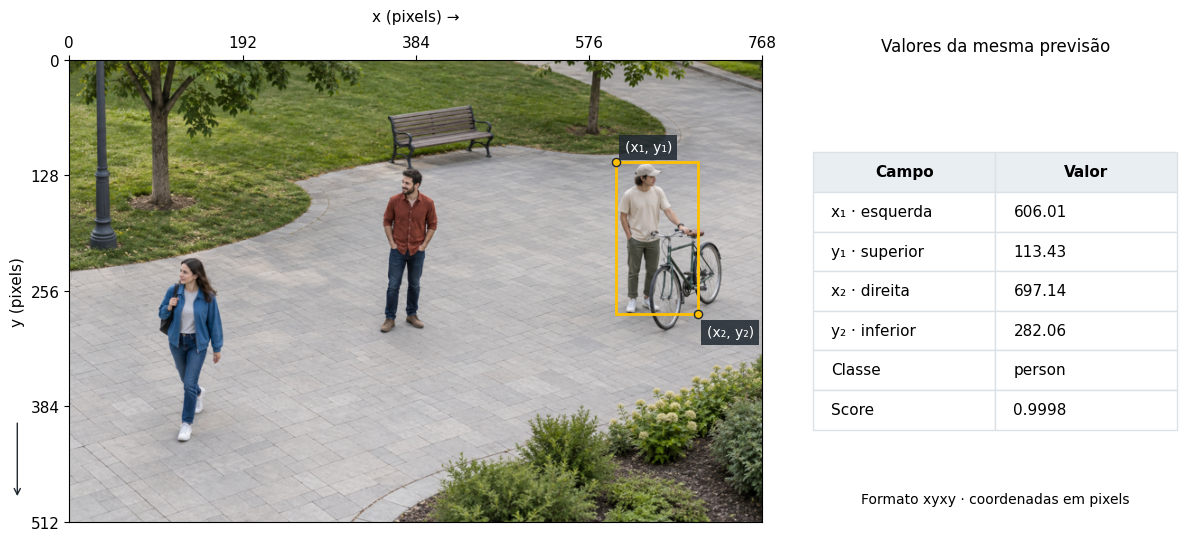

In [21]:
apoio.detalhar(imagem, caixa, classe, score)

No formato `xyxy`, os dois primeiros números são o canto superior esquerdo;
os dois últimos, o canto inferior direito. A origem está no canto superior
esquerdo da imagem: `x` cresce para a direita e `y`, para baixo.

As caixas retornadas estão em **pixels da imagem fornecida**, mesmo que o modelo
tenha redimensionado a entrada internamente. A figura arredonda os valores
somente para leitura; os tensores conservam a precisão da previsão.

**A mesma caixa pode ter outros formatos?**

Usaremos coordenadas inteiras para facilitar a comparação. O exemplo a seguir
foi escolhido manualmente; não é uma previsão da praça.

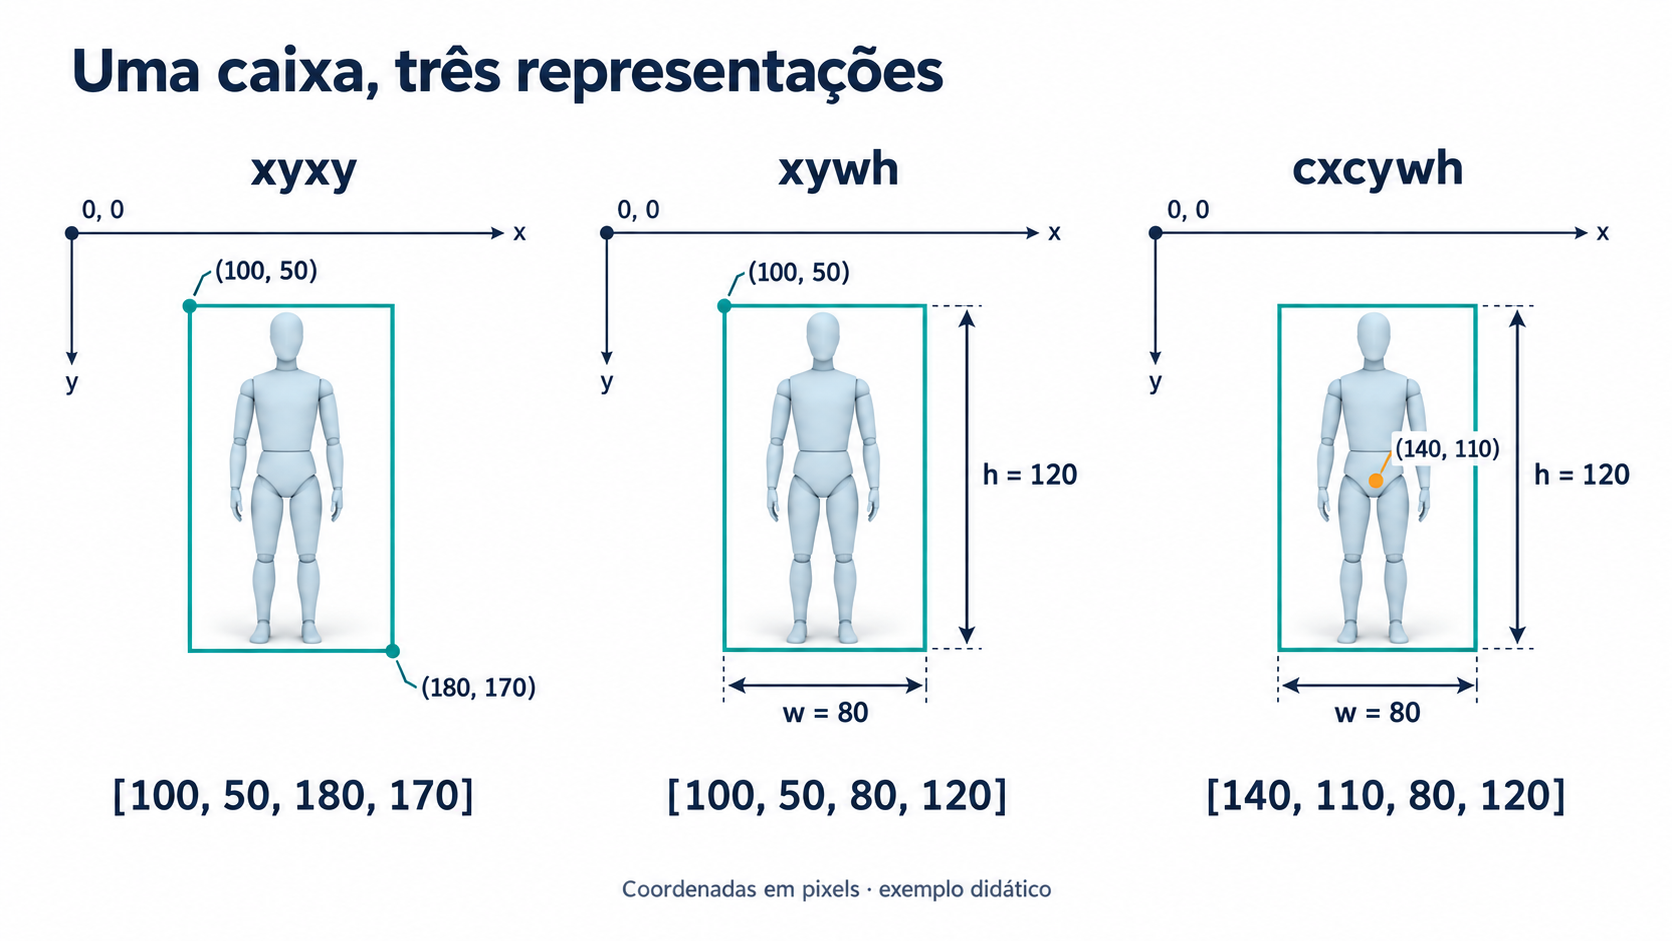

In [22]:
Image.open("formatos-caixas.png")

Ilustração esquemática, sem escala métrica, gerada por IA. As três representações
descrevem a mesma caixa; os pontos destacados indicam cantos ou centro.

In [23]:
exemplo = torch.tensor([[100., 50., 180., 170.]])
exemplo

tensor([[100.,  50., 180., 170.]])

Em `xywh`, preservamos o canto superior esquerdo e informamos largura e altura:
`w = x2 - x1` e `h = y2 - y1`. Em `cxcywh`, os dois primeiros valores representam
o centro: `cx = (x1 + x2) / 2` e `cy = (y1 + y2) / 2`.

In [24]:
xywh = box_convert(exemplo, in_fmt="xyxy", out_fmt="xywh")
xywh

tensor([[100.,  50.,  80., 120.]])

In [25]:
cxcywh = box_convert(exemplo, in_fmt="xyxy", out_fmt="cxcywh")
cxcywh

tensor([[140., 110.,  80., 120.]])

| Formato | Valores | Ponto de referência |
|---|---|---|
| `xyxy` | `[100, 50, 180, 170]` | Dois cantos opostos |
| `xywh` | `[100, 50, 80, 120]` | Canto superior esquerdo |
| `cxcywh` | `[140, 110, 80, 120]` | Centro |

A geometria foi preservada. Apenas sua representação mudou. Usamos coordenadas
contínuas: a largura é `180 - 100 = 80`, sem acrescentar 1.

Para revisar os eixos e as representações, consulte
[Dive into Deep Learning, seção 14.3.1](https://d2l.ai/chapter_computer-vision/bounding-box.html#bounding-boxes):
o texto define cantos e centro; a função `bbox_to_rect` usa canto, largura e altura.
O [Foundations of Computer Vision, seção 50.4.1](https://visionbook.mit.edu/object_recognition_v3.html)
também apresenta as representações por cantos e por centro.

**Os valores estão em pixels ou normalizados?**

Formato e unidade são decisões diferentes. Para expressar esse exemplo em
coordenadas relativas a uma imagem de 768 × 512, dividimos cada `x` pela largura
e cada `y` pela altura. O resultado abaixo continua no formato `xyxy`.

In [26]:
escala = torch.tensor([largura, altura, largura, altura])
normalizada = exemplo / escala
normalizada

tensor([[0.1302, 0.0977, 0.2344, 0.3320]])

Para recuperar os valores em pixels, basta multiplicar por `escala`.
Essa operação transforma coordenadas de caixas; não altera intensidades da imagem.

Ao consultar outra biblioteca, verifique a estrutura do retorno, a ordem das
coordenadas, o ponto de referência e a unidade. Um vetor com quatro números,
sem essa convenção, não determina como deve ser interpretado.

**Como selecionamos as detecções que serão exibidas?**

Vamos voltar às previsões reais guardadas em `saida`. O limiar seleciona scores
maiores ou iguais a 0,5. Um score alto não garante que a previsão esteja correta
e não deve ser tratado automaticamente como probabilidade calibrada de acerto.

In [27]:
limiar = 0.5
manter = saida["scores"] >= limiar
manter.sum().item()

6

In [28]:
caixas = saida["boxes"][manter].cpu()
classes = saida["labels"][manter].cpu()
scores = saida["scores"][manter].cpu()

A mesma máscara booleana foi aplicada aos três campos. Isso preserva a relação
entre caixa, classe e score. Vamos mostrar esses dados como uma tabela.

In [29]:
nomes = [categorias[c.item()] for c in classes]
apoio.tabela(caixas, nomes, scores)

Índice na seleção,x₁,y₁,x₂,y₂,Classe,Score
0,606.01,113.43,697.14,282.06,person,0.9998
1,97.81,221.80,170.91,422.99,person,0.9997
2,344.10,119.98,409.08,302.97,person,0.9993
3,352.84,50.18,470.03,119.08,bench,0.9987
4,640.72,189.26,724.04,300.01,bicycle,0.9976
5,100.40,247.82,123.99,304.53,handbag,0.8818


**Como os dados se tornam uma imagem anotada?**

Vamos usar as mesmas caixas e acrescentar textos para exibição. As cores,
a espessura dos retângulos e a tipografia pertencem à visualização.
O auxiliar abaixo recebe os dados e desenha; ele não executa o detector.

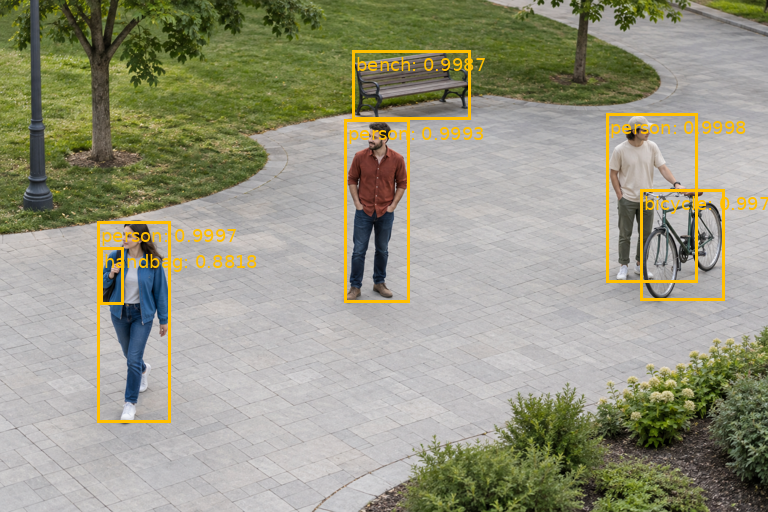

In [30]:
rotulos = [f"{nome}: {s:.4f}" for nome, s in zip(nomes, scores.tolist())]
apoio.mostrar_caixas(imagem, caixas, rotulos)

O processamento pode ser separado em três responsabilidades:

| Momento | Resultado |
|---|---|
| Rede e pós-processamento interno do detector | Previsões numéricas em `boxes`, `labels` e `scores` |
| Seleção pelo nosso limiar | Subconjunto das previsões já calculadas |
| Visualização | Imagem com retângulos e textos |

No Faster R-CNN do TorchVision, o retorno já inclui o pós-processamento interno,
como a supressão de determinadas caixas sobrepostas. Não estamos inspecionando
as saídas brutas das cabeças da rede. A imagem anotada é produzida posteriormente.

**Experimentos para revisão**

1. Altere `indice` para outra detecção válida e reexecute apenas a leitura dos
   campos e `apoio.detalhar(...)`. Relacione cada coordenada ao objeto correspondente.
2. Altere `limiar` para `0.9` e reexecute a seleção, a tabela e o desenho.
   Quais previsões saíram? Os scores guardados em `saida` mudaram?
3. Na criação de `rotulos`, use `rotulos = nomes` e reexecute o desenho.
   O desaparecimento do score da legenda alterou a previsão?
4. Converta `cxcywh` de volta para `xyxy` com `box_convert` e compare com `exemplo`.

Nenhum desses experimentos exige outra inferência. Ao terminar, restaure os
valores originais e execute as células em ordem.

A cena sintética demonstra a interpretação da interface. Avaliar um detector
para drones exige dados representativos do voo e comparação com anotações de referência.

Referências para consulta:

- [TorchVision: entrada e saída do Faster R-CNN](https://docs.pytorch.org/vision/stable/models/generated/torchvision.models.detection.fasterrcnn_resnet50_fpn.html)
- [TorchVision: pesos e transformações do modelo v2](https://docs.pytorch.org/vision/stable/models/generated/torchvision.models.detection.fasterrcnn_resnet50_fpn_v2.html)
- [TorchVision: conversão de formatos de caixas](https://docs.pytorch.org/vision/stable/generated/torchvision.ops.box_convert.html)
- [TorchVision: desenho de bounding boxes](https://docs.pytorch.org/vision/stable/generated/torchvision.utils.draw_bounding_boxes.html)
- [Fast R-CNN: compartilhamento de características](https://arxiv.org/abs/1504.08083)
- [Faster R-CNN: propostas e detecção](https://arxiv.org/abs/1506.01497)
- [FCOS: exemplo de detector de uma etapa](https://arxiv.org/abs/1904.01355)
- [SAHI: inferência por recortes para objetos pequenos](https://arxiv.org/abs/2202.06934)

As figuras da praça são calculadas a partir dos pixels e das previsões desta execução.
As coordenadas inteiras da comparação de formatos são um exemplo didático manual.